# **Criação do operador AND aplicado à fusão multimodal**
---




### **Agora, será feira a função do AND para ser aplicada à base de vídeos**




In [1]:
def andOperator(visual, aural):
    #andFused = visual.copy()
    andFused = []
    andList = []
    qtdTomadas = len(visual)
    tamHist = len(visual[0])

    print("TamHist: ", tamHist)
    print("visual: ",len(visual[0]), visual[0])
    print("aural: ", aural[0])

    for tomada in range(qtdTomadas):
        v = visual[tomada]
        a = aural[tomada]
        for i in range (tamHist):
            andFused.append(int(a[i])&int(v[i]))
        andList.append(andFused)
        andFused = []
    print("AND: ", len(andList[0]), andList[0])
    return (andList)

# Agora, aplicaremos essa função na fusão multimodal

## Preparação do ambiente do Notebook





**Instalando Dependências**

In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

**Acesso ao Drive - para armazenamento de Arquivos**

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


TamHist:  100
visual:  100 [0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 4. 0.
 0. 2. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 0. 0. 2. 0.
 0. 0. 0. 0. 0. 1. 0. 2. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 2.
 0. 0. 0. 0. 0. 3. 0. 0. 2. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0.]
aural:  [  0.   1.  21.   0.   0.   0.   0.   1.   0.   0.  12.   0.   0.   0.
   0.  77.   0.   0.   0.   0.   0.   0.   0. 307.   0.   1.  44.   0.
   0.   0.   0.   0.  76.   0.   0.   0.   3.   0.   0.   0.  89.  45.
   0.   0. 154. 209.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   1.  21.  38.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   4.   0.   7.   0.   7.
   2.   0.   0.   0.   0.  51.   0.   1.   0.   0.  11.   0.  84.   0.
   0.   0.]
AND:  100 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

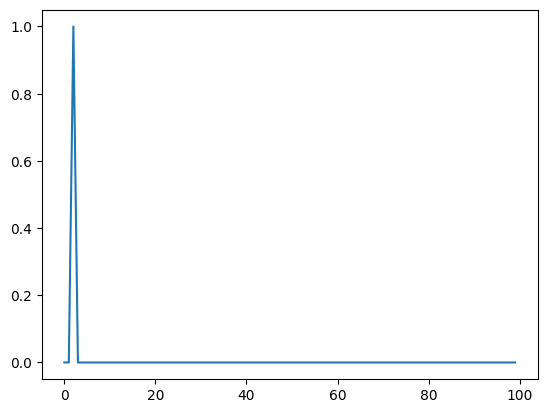

In [4]:
visualHistogram = []

#Recuperando representação monomodal visual previamente computada e salva em arquivo
#O número ao fim do nome do arquivo indica a dimesão de cada histograma, que vem
#do tamanho do dicionário usado para gerar a representação monomodal.
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Visuais/visual_histogram_100_cosine_bbc_10.arq', 'rb') as arq1:
#with open('/content/drive/MyDrive/Dataset_BBC/Histograms/visual_histogram_bbc_01_100_cosine.arq', 'rb') as arq1:
    visualHistogram = pickle.load(arq1)


#Idem para a reprensentação monomodal aural.
auralHistogram = []
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Aurais/aural_histogram_100_cosine_bbc_10.arq', 'rb') as arq2:
#with open('/content/drive/MyDrive/Dataset_BBC/Histograms/aural_histogram__bbc_01_100_cosine.arq', 'rb') as arq2:
    auralHistogram = pickle.load(arq2)

#Aplicando o operador de fusão.
multiModalHistogram = andOperator(visualHistogram, auralHistogram)

#Salvado  os histogramas em arquivo
#A pasta "histogramas" deve existir dentro de "MBA_Curso14_Dados"
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Multimodais_AND/mm_and_histogram_bbc_10_100_cosine.arq', 'wb') as arq_mm:
#with open('/content/drive/MyDrive/Dataset_BBC/Histograms/mm_and_histogram_bbc_01_100_cosine.arq', 'wb') as arq_mm:
    pickle.dump(multiModalHistogram, arq_mm)

#Imprimindo o histograma multimodal do 1o vídeo da base
print("Multimodal: ", multiModalHistogram[0])

plt.plot(multiModalHistogram[0])
plt.show()